# Лабораторная работа - Корреляционный анализ в Python


### Цели

* Часть 1: Набор данных
* Часть 2: Диаграммы рассеяния и корреляционные переменные
* Часть 3: Расчёт корреляции с Python
* Часть 4: Визуализация

### История / Cценарий

Корреляция является важной статистической зависимостью, которая может указывать, связаны ли линейные значения переменных.

В этой лабораторной работе вы узнаете, как использовать Python для расчета корреляции. В Части 1 Вы подготовите набор данных. В Части 2 Вы узнаете, как определить, являются ли переменные в данном наборе данных взаимозависимыми. Наконец, в Части 3, Вы будете использовать Python для вычисления корреляции между двумя наборами переменных.

### Необходимо:
* Библиотеки Python: pandas, numpy, matplotlib, seaborn
* Файл данных: brainsize.txt

## Часть 1: Набор данных

Вы будете использовать набор данных, который содержит выборку 40 студентов правшей с вводного курса по Психологии из университета Southwestern. Испытуемые прошли четыре субтеста (Vocabulary, Similarities, Block Design, и Picture Completion) для расчёта шкалы интеллекта взрослых по Векслеру. Исследователи использовали магнитно-резонансную томографию (МРТ) для определения размера мозга у субъектов. Также включены сведения о гендерных показателях и размере тела (рост и вес). Исследователи скрыли вес двух испытуемых и высоту одного из них по причинам конфиденциальности.
Для набора данных были применены две простые модификации:

1. Заменены вопросительные знаки, используемые для представления скрытых данных, описанных выше, строкой «NaN». Замена была выполнена, потому что Pandas не обрабатывает вопросительные знаки правильно.

2. Заменены все символы табуляции запятыми, преобразуя набор данных в набор данных CSV.

Готовый набор данных сохранён как `brainsize.txt`.

#### Шаг 1: Загрузка набора данных из файла.

До того, как набор данных можно использовать, он должен быть загружен в память.

В приведенном ниже коде первая строка импортирует модули `pandas` и определяет `pd` как дескриптор, который ссылается на один из модулей.

Вторая строка загружает CSV-файл набора данных в переменную с именем `brainFile`.

Третья строка использует метод `read_csv()` из библиотеки `pandas`, чтобы преобразовать набор данных CSV, хранящийся в `brainFile` в кадр данных. Затем кадр данных хранится в переменной `brainFrame`.

Запустите ячейку ниже, чтобы выполнить описанные функции.

In [2]:
import pandas as pd

# читаем файл с разделителем табуляции (\t), NaN уже прописаны в файле
brainFrame = pd.read_csv('brainsize.txt', delimiter='\t')

#### Шаг 2. Проверка кадра данных.

Чтобы убедиться, что кадр данных правильно загружен и создан, используйте метод `head()`. Метод `head()` отображает первые пять записей в кадре данных.

In [3]:
brainFrame.head()

,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
0,Female,133,132,124,118.0,64.5,816932
1,Male,140,150,124,NaN,72.5,1001121
2,Male,139,123,150,143.0,73.3,1038437
3,Male,133,129,128,172.0,68.8,965353
4,Female,137,132,134,147.0,65.0,951545


Метод head() принимает параметр - число строк, отобразите первые 10 строк таблицы

In [4]:
brainFrame.head(10)

,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
0,Female,133,132,124,118.0,64.5,816932
1,Male,140,150,124,NaN,72.5,1001121
2,Male,139,123,150,143.0,73.3,1038437
3,Male,133,129,128,172.0,68.8,965353
4,Female,137,132,134,147.0,65.0,951545
5,Female,99,90,110,146.0,69.0,928799
6,Female,138,136,131,138.0,64.5,991305
7,Female,92,90,98,175.0,66.0,854258
8,Male,89,93,84,134.0,66.3,904858
9,Male,133,114,147,172.0,68.8,955466


Также Dataframe имеет метод tail(), который возвращает последние 5 строк кадра данных. Аналогично head() метод tail() принимает аргументом число строк, которые он вернет. Отобразите последние 8 строк таблицы.

In [5]:
brainFrame.tail(8)

,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
32,Male,103,96,110,192.0,75.5,997925
33,Male,90,96,86,181.0,69.0,879987
34,Female,83,90,81,143.0,66.5,834344
35,Female,133,129,128,153.0,66.5,948066
36,Male,140,150,124,144.0,70.5,949395
37,Female,88,86,94,139.0,64.5,893983
38,Male,81,90,74,148.0,74.0,930016
39,Male,89,91,89,179.0,75.5,935863


## Часть 2: Диаграммы рассеяния и корреляционные переменные

#### Шаг 1: метод `describe()` в библиотеке pandas.
Библиотека pandas включает в себя метод `describe()`, который выполняет одни и те же общие вычисления на предложенном наборе данных. Помимо базовых операций таких, как подсчёт, расчёт среднего значения, расчёт среднеквадратического отклонения, расчёт минимума, и максимума,  `describe()` также отличный способ быстро проверить достоверность значений в кадре данных.<p>
Ниже используйте функцию describe, для вывода статистики по данным

In [6]:
# describe() выводит count, mean, std, min, 25%, 50%, 75%, max для каждого числового столбца
brainFrame.describe()

,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
count,40.000000,40.000000,40.00000,38.000000,39.000000,4.000000e+01
mean,113.450000,112.350000,111.02500,151.052632,68.525641,9.087550e+05
std,24.082071,23.616107,22.47105,23.478509,3.994649,7.228205e+04
min,77.000000,71.000000,72.00000,106.000000,62.000000,7.906190e+05
25%,89.750000,90.000000,88.25000,135.250000,66.000000,8.559185e+05
50%,116.500000,113.000000,115.00000,146.500000,68.000000,9.053990e+05
75%,135.500000,129.750000,128.00000,172.000000,70.500000,9.500780e+05
max,144.000000,150.000000,150.00000,192.000000,77.000000,1.079549e+06


#### Шаг 2: Диаграммы рассеяния

Диаграммы рассеяния важны при работе с корреляциями, поскольку они позволяют быстро визуально проверить природу связи между переменными. В этой лабораторной работе используется коэффициент корреляции Пирсона, который чувствителен только к линейной зависимости между двумя переменными. Также существуют другие более надежные методы корреляции, но они выходят за рамки этой лабораторной работы.

##### a. Загрузите необходимые модули.
Прежде чем строить графики, необходимо импортировать несколько модулей, а именно `numpy` и `matplotlib`. Запустите ячейку ниже, чтобы загрузить эти модули.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

##### b. Разделите данные.
Чтобы гарантировать, что результаты не будут искажены из-за различий в мужских и женских телах, кадр данных разбит на два: один содержит все мужские записи, а другой - только женские экземпляры. <p>
Создайте два новых кадра данных: menDf и womenDf, каждый из которых содержит соответствующие записи.

In [8]:
# фильтруем строки по значению столбца Gender
menDf   = brainFrame[brainFrame['Gender'] == 'Male']
womenDf = brainFrame[brainFrame['Gender'] == 'Female']

##### c. Постройте графики.
Поскольку набор данных включает в себя три различных измерения интеллекта (PIQ, FSIQ и VIQ), первая строка ниже использует метод `mean()` из библиотеки Pandas для вычисления среднего значения между тремя измерениями и сохранения результата в переменной `menMeanSmarts`. Обратите внимание, что первая строка относится к menDf, отфильтрованному кадру данных, содержащему только мужские записи.<p>
Вторая строка использует метод `scatter()` библиотеки `matplotlib` для создания графика диаграммы рассеяния между переменной `menMeanSmarts` и атрибутом `MRI_Count`. MRI_Count в этом наборе данных можно рассматривать как меру физического размера мозга испытуемых.<p>
Третья строка просто отображает график.<p>
Четвертая строка используется для гарантированного отображения графика в этом блокноте.

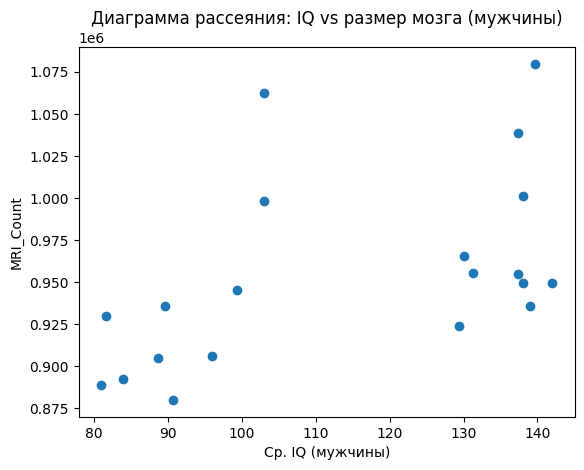

In [9]:
# Ячейка для кода № 6
# axis=1 — среднее по строке (по трём IQ-показателям для каждого человека)
menMeanSmarts = menDf[["PIQ", "FSIQ", "VIQ"]].mean(axis=1)
# scatter: ось X — средний IQ, ось Y — размер мозга по МРТ
plt.scatter(menMeanSmarts, menDf["MRI_Count"])
plt.xlabel("Ср. IQ (мужчины)")
plt.ylabel("MRI_Count")
plt.title("Диаграмма рассеяния: IQ vs размер мозга (мужчины)")
plt.show()
%matplotlib inline

Аналогичным образом создайте график диаграммы рассеяния для кадра данных, содержащему только женские записи.

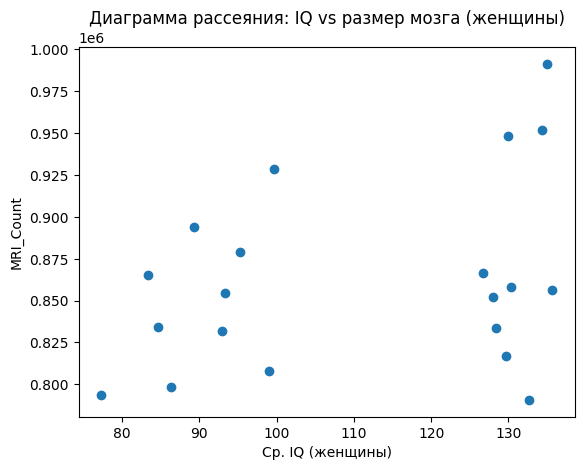

In [10]:
# Ячейка для кода № 7
# Считаем средний IQ по трём показателям для каждой женщины
womenMeanSmarts = womenDf[["PIQ", "FSIQ", "VIQ"]].mean(axis=1)
# Строим диаграмму рассеяния: средний IQ vs размер мозга
plt.scatter(womenMeanSmarts, womenDf["MRI_Count"])
plt.xlabel("Ср. IQ (женщины)")
plt.ylabel("MRI_Count")
plt.title("Диаграмма рассеяния: IQ vs размер мозга (женщины)")
plt.show()
%matplotlib inline

## Часть 3: Вычисление корреляции с Python


#### Шаг 1: Рассчитайте корреляцию для brainFrame.
Метод `corr()` библиотеки pandas обеспечивает простой способ вычисления корреляции для кадра данных. Просто применяя метод на кадре данных, можно получить корреляцию между всеми переменными одновременно.

In [11]:
# corr(method='pearson') вычисляет коэффициент корреляции Пирсона для всех пар числовых столбцов
# исключаем столбец Gender, оставляем только числовые столбцы(т.к. он содержит строки и их нельзя преобразовать в числа)
brainFrame.drop(columns=['Gender']).corr(method='pearson')

,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
FSIQ,1.000000,0.946639,0.934125,-0.051483,-0.086002,0.357641
VIQ,0.946639,1.000000,0.778135,-0.076088,-0.071068,0.337478
PIQ,0.934125,0.778135,1.000000,0.002512,-0.076723,0.386817
Weight,-0.051483,-0.076088,0.002512,1.000000,0.699614,0.513378
Height,-0.086002,-0.071068,-0.076723,0.699614,1.000000,0.601712
MRI_Count,0.357641,0.337478,0.386817,0.513378,0.601712,1.000000


Обратите внимание на диагональ слева направо в таблице корреляции, сгенерированной выше. Почему диагональ заполнена значениями 1? Это совпадение? Объясните.

**Ответ:** Диагональ всегда равна 1 - это не совпадение. Каждый элемент на диагонали - корреляция переменной с самой собой.
По определению коэффициента Пирсона, любая переменная полностью линейно связана с собой: когда одна изменяется, вторая (та же самая) изменяется ровно так же. Поэтому корреляция = 1 всегда и для любого набора данных

Продолжая смотреть на таблицу корреляции выше, обратите внимание, что значения зеркалируются; значения под диагональю имеют зеркальный аналог над ней. Это совпадение? Объясните.

**Ответ:** Нет, это не совпадение. Корреляция симметрична по определению: corr(A, B) = corr(B, A). Коэффициент Пирсона измеряет степень линейной связи между двумя переменными, и эта связь не зависит от того, какую переменную считать «первой», поэтому матрица корреляций всегда является симметричной

Используя тот же метод `corr()`, вычислите корреляцию переменных, содержащихся в кадре с женскими записями:

In [12]:
# корреляция Пирсона только для женских данных
womenDf.drop(columns=['Gender']).corr(method='pearson')

,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
FSIQ,1.000000,0.955717,0.939382,0.038192,-0.059011,0.325697
VIQ,0.955717,1.000000,0.802652,-0.021889,-0.146453,0.254933
PIQ,0.939382,0.802652,1.000000,0.113901,-0.001242,0.396157
Weight,0.038192,-0.021889,0.113901,1.000000,0.552357,0.446271
Height,-0.059011,-0.146453,-0.001242,0.552357,1.000000,0.174541
MRI_Count,0.325697,0.254933,0.396157,0.446271,0.174541,1.000000


И то же самое можно сделать для переменных, содержащихся в кадре с мужскими записями:

In [13]:
# для мужчин
menDf.drop(columns=['Gender']).corr(method='pearson')

,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
FSIQ,1.000000,0.944400,0.930694,-0.278140,-0.356110,0.498369
VIQ,0.944400,1.000000,0.766021,-0.350453,-0.355588,0.413105
PIQ,0.930694,0.766021,1.000000,-0.156863,-0.287676,0.568237
Weight,-0.278140,-0.350453,-0.156863,1.000000,0.406542,-0.076875
Height,-0.356110,-0.355588,-0.287676,0.406542,1.000000,0.301543
MRI_Count,0.498369,0.413105,0.568237,-0.076875,0.301543,1.000000


## Часть 4: Визуализация

#### Шаг 1: Установите Seaborn.
Чтобы упростить визуализацию корреляций данных, можно использовать тепловую карту. На основе цветных квадратов тепловая карта может помочь выявить корреляции с первого взгляда.

Модуль Python с именем `seaborn` очень упрощает построение тепловых карт.

Сначала запустите ячейку ниже, чтобы загрузить и установить модуль `seaborn`. (закомментируйте, если библиотека установлена)

In [14]:
# Ячейка для кода № 11
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Шаг 2: Нарисуйте корреляционную тепловую карту.

Теперь, когда кадры данных готовы, можно отобразить тепловые карты. Далее приведен анализ кода из ячейки ниже:

Строка 1: Создает таблицу корреляции, основанную на фрейме данных `womenNoGenderDf` и хранит его в `wcorr`.<br>
Строка 2: Использует метод `heatmap()` библиотеки `seaborn` для генерации и построения тепловой карты. Обратите внимание, что `heatmap()` принимает `wcorr`, как параметр.<br>
Строка 3: используется для экспорта и сохранения созданной тепловой карты в виде PNG-изображения. Хотя строка 3 не активна (перед ней стоит символ `#`, заставляя интерпретатор игнорировать ее), она сохранена в информационных целях.

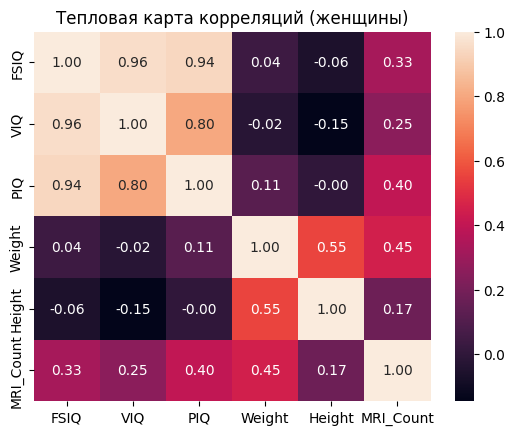

In [15]:
# Ячейка для кода № 12
import seaborn as sns

# wcorr - матрица корреляций для женских данных
wcorr = womenDf.drop(columns=['Gender']).corr()
# heatmap раскрашивает ячейки: тёплые цвета = сильная положительная корреляция
sns.heatmap(wcorr, annot=True, fmt='.2f')
plt.title("Тепловая карта корреляций (женщины)")
plt.show()
#plt.savefig('attribute_correlations.png', tight_layout=True)

Аналогичным образом создайте и отобразите тепловую карту для кадра данных с мужчинами.

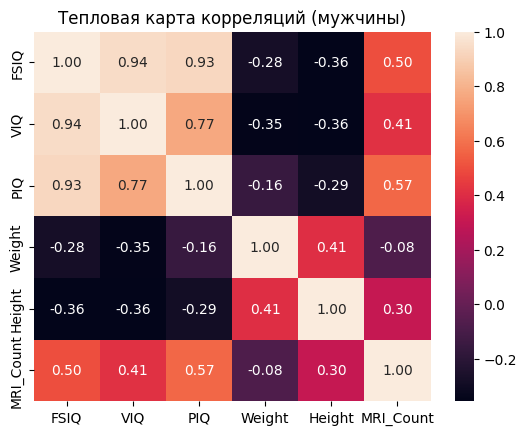

In [16]:
# Ячейка для кода № 14
# mcorr — матрица корреляций для мужских данных
mcorr = menDf.drop(columns=['Gender']).corr()
# строим тепловую карту для мужчин
sns.heatmap(mcorr, annot=True, fmt='.2f')
plt.title("Тепловая карта корреляций (мужчины)")
plt.show()

У многих пар переменных корреляция близка к нулю. Что это значит?

**Ответ:** Корреляция, близкая к нулю, означает отсутствие линейной зависимости между двумя переменными. То есть изменение одной переменной никак не предсказывает изменение другой. допустим, рост человека практически не связан с его уровнем IQ - это биологически независимые характеристики

Зачем делать разделение по полу?

**Ответ:** Мужчины и женщины в среднем различаются по физическим параметрам (рост, вес, размер мозга). Если объединить данные, эти биологические различия могут исказить корреляции: связь между размером мозга и весом может объясняться тем, что мужчины в среднем тяжелее и имеют больший мозг, а не реальной зависимостью этих признаков внутри одного пола. Разделение по полу позволяет получить более достоверные результаты

Какие переменные имеют более сильную корреляцию с размером мозга (MRI_Count)? Это ожидалось? Объясните.

**Ответ:** Наиболее сильную корреляцию с MRI_Count показывают физические параметры - вес (Weight) и рост (Height), что вполне ожидаемо: у людей с большим телом, как правило, и мозг физически крупнее. Показатели интеллекта (FSIQ, VIQ, PIQ) имеют слабую корреляцию с размером мозга.

Вывод: физический размер мозга не является надёжным предиктором уровня интеллекта